# **Problem Statement 1: Tic Tac Toe**

* The aim is to design a stimulating and enjoyable three-player Tic-Tac-Toe game that operates within a larger framework, challenging players' strategic thinking and adaptability in a multi-player context.  
* Create a three-player Tic-Tac-Toe game utilizing Python, featuring an expanded 9x9 grid. The game must adhere to the following guidelines and stipulations:  

In [ ]:
# Importing libraries
import numpy as np
import random
from time import sleep
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
# Constants representing the Assignment Questions Constraints
BOARD_SIZE = 9                             # Constant to define the size of the Board
PLAYER_COUNT = 3                            # Constant to define the # of players in game
MANUAL_PLAYER_COUNT = 1                    # Constant to define the # of manual player in game
WIN_CONSECUTIVE_COUNT = 5                  # Constant to define the # consecutive box to win
MAX_RANDOM_COUNTER_CHOICE = 2              # Constant to define first 2 game as random for performance

In [ ]:
# Method to create a User size defined board
def createNiceTicTacSquareBoardOfAnySizeAsYouPlease(size):
    if not isinstance(size, int) or size <= 0:
        raise ValueError("The Board Configuration should be greater than 0")
    return np.zeros((size, size))

In [ ]:
# Method to get any count of players to play
def createPlayersAsYouPlease(playerCount):
    if not isinstance(playerCount, int) or playerCount <= 1:
        raise ValueError("It takes 2 to Tic-Tac-Toe")
    return list(range(1, playerCount + 1))

In [ ]:
# Method to create players based on player count
def getAllPlayers():
    return createPlayersAsYouPlease(PLAYER_COUNT)

In [ ]:
# Method to display tic tac toe board using matplotlib
def displayTicTacToe(board, title="Tic Tac Toe", cmap="viridis", symbol1="X", symbol2="O", symbol3="Y"):
    """Displays a dynamic Tic-Tac-Toe board with values and dynamic size."""
    color_map = {
        0: 'lightgray',
        1: 'skyblue',
        2: 'red',
        3: 'lightgreen',
    }
    value_map = {
        0: '',
        1: symbol1,  # Human's symbol
        2: symbol2,  # Player 2's symbol
        3: symbol3,  # Player 3's symbol
    }
    rows, cols = board.shape
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))

    ax.set_yticklabels(np.arange(cols)[::-1])

    # Draw rectangles first
    for i in range(rows):
        for j in range(cols):
            value = board[i, j]
            color = color_map.get(value, 'white')
            symbol = value_map.get(value, str(value))

            rect = patches.Rectangle((j - 0.5, rows - 1.5 - i), 1, 1, linewidth=1, edgecolor='black', facecolor=color)
            ax.add_patch(rect)
            text = ax.text(j, rows - 1 - i, symbol, ha='center', va='center', fontsize=20)

    # Draw grid lines on top
    for i in range(cols + 1):
        ax.axvline(i - 0.5, color='black', linewidth=1)
    for i in range(rows + 1):
        ax.axhline(i - 0.5, color='black', linewidth=1)
    plt.title(title)
    plt.show()

In [ ]:
# Creates an empty board
def create_board():
    return createNiceTicTacSquareBoardOfAnySizeAsYouPlease(BOARD_SIZE)

In [ ]:
# Check for empty places on board
def possibilities(board):
    l = []
    for i in range(len(board)):
        for j in range(len(board)):
            if board[i][j] == 0:
                l.append((i, j))
    return l

***Static Evaluation Function:***



The static_evaluation function is a heuristic that estimates the strategic value of a board position in the Tic Tac Toe game. It does this by looking for sequences of pieces and assigning scores based on their length. This information is then used by the AI to make informed decisions about its next move.
The static evaluation function assigns a score for the players position at any given state in the game.
1. A dictionary is created to store the scores for each player. 2. Initially, all scores are set to 0.
3. Then we traverse through the four direction and checks for sequences of the same player's pieces in all four directions and assigns count of the sequences.
4. Based on the count, it updates the score for the current player. Sequences with more length has more points.
5. The method at the end returns the score of all the players at any given moment.

*Please check the attached word document (Theory) for calculation using a sample state*


In [ ]:
# Static evaluation method
def static_evaluation(board):
    """Static evaluation method that counts open sequences of length 2, 3, or 4."""
    scores = {1: 0, 2: 0, 3: 0}  # Scores for Human, Player 2, and Player 3
    directions = [(0, 1), (1, 0), (1, 1), (-1, 1)]  # Right, Down, Diagonal Right-Down, Diagonal Right-Up

    for i in range(BOARD_SIZE):
        for j in range(BOARD_SIZE):
            player = board[i][j]
            if player == 0:
                continue  # Skip empty cells

            for dr, dc in directions:
                count = 1
                r, c = i + dr, j + dc
                while 0 <= r < BOARD_SIZE and 0 <= c < BOARD_SIZE and board[r][c] == player:
                    count += 1
                    r += dr
                    c += dc

                # Assign score based on length
                if count == 2:
                    scores[player] += 2
                elif count == 3:
                    scores[player] += 5
                elif count == 4:
                    scores[player] += 10

    return (scores[1], scores[2], scores[3])

***minimax algorithm using alpha beta pruning method:***

* The minimax function implements the Minimax algorithm with alpha-beta pruning for decision-making
* It recursively evaluates the possible moves by alternating between maximizing and minimizing players.
* The algorithm uses alpha-beta pruning to eliminate branches in the game tree that won't be selected, improving efficiency.
* The function returns the best move and its corresponding score by evaluating all possible moves up to a specified depth or until a terminal state (win/loss) is reached.

In [1]:
# minimax algorithm using alpha beta pruning method

# 1. Check the current state whether it is win or lose or np.deprecate_with_doc
# 2. Call Static Evaluation method to get the score of the current state for all players
# 3. Generate possible moves
# 4. Recursively evaluates each move by alternating between maximizing and minimizing
# 5. During the recursion, alpha and beta values are used to prune branches that cannot possibly affect the outcome.
#     If the current score is worse than a previously explored move (i.e., when beta <= alpha),
#     the algorithm stops exploring further moves on that branch, saving computation time.
# 6. The function returns the best move and its corresponding score by evaluating all possible moves up to a specified depth
#     or until a terminal state (win/loss) is reached.

def minimax(board, depth, player, alpha=-float('inf'), beta=float('inf'), maximizing=True):
    winner = evaluate(board)
    if winner != 0:  # If a player has won, return immediately
        return (None, winner if winner != -1 else 0)

    if depth == 0:  # If depth limit is reached, use static evaluation
        scores = static_evaluation(board)
        return (None, scores[player - 1] - max([scores[i] for i in range(PLAYER_COUNT) if i != player-1]))

    moves = possibilities(board)
    moves.sort(key=lambda move: abs(move[0] - BOARD_SIZE // 2) + abs(move[1] - BOARD_SIZE // 2))  # Prioritize center moves

    if maximizing:
        best_score = -float('inf')
        best_move = None
        for move in moves:
            board[move] = player
            _, score = minimax(board, depth - 1, (player % PLAYER_COUNT) + 1, alpha, beta, False)
            board[move] = 0
            if score > best_score:
                best_score = score
                best_move = move
            alpha = max(alpha, best_score)
            if beta <= alpha:
                break  # Prune branch
        return best_move, best_score
    else:
        best_score = float('inf')
        best_move = None
        for move in moves:
            board[move] = player
            _, score = minimax(board, depth - 1, (player % PLAYER_COUNT) + 1, alpha, beta, True)
            board[move] = 0
            if score < best_score:
                best_score = score
                best_move = move
            beta = min(beta, best_score)
            if beta <= alpha:
                break  # Prune branch
        return best_move, best_score

In [ ]:
def ai_place(board, player):
    move, _ = minimax(board, depth=2, player=player)  # Reduced depth for faster computation
    if move:
        board[move] = player

# Method to get Player's symbol choice
def get_player_symbol():
    while True:
        symbol = input("Human Player, Choose your symbol (X/O/Y): ").upper()
        if symbol in ['X', 'O', 'Y']:
            return symbol
        else:
            print("Invalid input. Please choose 'X', 'O', or 'Y'.")

def get_player_type(player):
    if player == 1:  # Assuming Player 1 and Player 2 are human
        return "Human"
    else:  # Assuming Player 3 is AI
        return "AI"

# Method to decide who will start first
def choose_first_player():
    while True:
        first_player = input("Who will start first? (1 for Human Player, 2 for AI Player 1, 3 for AI Player 2): ")
        if first_player in ['1', '2', '3']:
            return int(first_player)
        else:
            print("Invalid input. Please choose '1', '2', or '3'.")

In [ ]:
# Checking win condition based on row, column and diagonal
def row_win(board, player, consecutive_count=WIN_CONSECUTIVE_COUNT):
    rows, cols = board.shape
    for row in range(rows):
        for start_col in range(cols - consecutive_count + 1):
            if all(board[row, start_col + i] == player for i in range(consecutive_count)):
                return True
    return False

def col_win(board, player, consecutive_count=WIN_CONSECUTIVE_COUNT):
    rows, cols = board.shape
    for col in range(cols):
        for start_row in range(rows - consecutive_count + 1):
            if all(board[start_row + i, col] == player for i in range(consecutive_count)):
                return True
    return False


def diag_win(board, player, consecutive_count=WIN_CONSECUTIVE_COUNT):
    rows, cols = board.shape

    # Check forward diagonals (top-left to bottom-right)
    for row in range(rows - consecutive_count + 1):
        for col in range(cols - consecutive_count + 1):
            if all(board[row + i, col + i] == player for i in range(consecutive_count)):
                return True

    # Check backward diagonals (top-right to bottom-left)
    for row in range(rows - consecutive_count + 1):
        for col in range(consecutive_count - 1, cols):
            if all(board[row + i, col - i] == player for i in range(consecutive_count)):
                return True

    return False

In [ ]:
# Make a move based on manual or AI input
def makeMove(board, player, counter, symbol1, symbol2, symbol3):
    selection = possibilities(board)
    if player == 1:
        symbol = symbol1
    elif player == 2:
        symbol = symbol2
    else:
        symbol = symbol3

    if player <= MANUAL_PLAYER_COUNT:
        while True:
            try:
                # iRow = int(input(f"Human, Enter Row (0-{BOARD_SIZE-1}): "))
                # iCol = int(input(f"Human, Enter Column (0-{BOARD_SIZE-1}): "))
                user_input = input(f"Turn for Human Player, Enter Row and Column below (0-{BOARD_SIZE-1}) with space. Eg. <rowno> <colno> (0 0): \n")
                iRow, iCol = map(int, user_input.split())
                if (iRow, iCol) in selection:
                    board[iRow][iCol] = player
                    break
                else:
                    print("Invalid move, try again.")
            except ValueError:
                print("Invalid input, enter integers.")
    else:
      ai_place(board, player)
    return board

In [ ]:
# Evaluates whether there is a winner or a tie
def evaluate(board):
    winner = 0
    for player in getAllPlayers():
        if (row_win(board, player) or
                col_win(board, player) or
                diag_win(board, player)):
            winner = player
    if np.all(board != 0) and winner == 0:
        winner = -1
    return winner

In [ ]:
# Main function to start the game
def play_game():
    print("*** Let's Play Tic Tac Toe *** \n")
    symbol1 = get_player_symbol()
    symbol2 = 'O' if symbol1 == 'X' else 'X'
    symbol3 = 'Y' if symbol1 != 'Y' and symbol2 != 'Y' else ('Z' if symbol1 != 'Z' and symbol2 != 'Z' else 'A')
    first_player = choose_first_player()

    board, winner, counter = create_board(), 0, 1
    displayTicTacToe(board, title="Tic Tac Toe Game", symbol1=symbol1, symbol2=symbol2, symbol3=symbol3)

    # Start with the selected first player and continue with the cyclic turn order
    player = first_player
    while winner == 0:
        # Make a move for the current player
        board = makeMove(board, player, counter, symbol1, symbol2, symbol3)

        print("Board after " + str(counter) + " move")
        displayTicTacToe(board, title="Tic Tac Toe Game", symbol1=symbol1, symbol2=symbol2, symbol3=symbol3)

        # Increment the move counter and check for the winner
        counter += 1
        winner = evaluate(board)

        # If there's no winner, move to the next player in a cyclic manner
        if winner == 0:
            player = (player % PLAYER_COUNT) + 1

        winner_type = get_player_type(winner)
    return f"Player {winner} ({winner_type})"


*** Let's Play Tic Tac Toe *** 

Human Player, Choose your symbol (X/O/Y): X
Who will start first? (1 for Human Player, 2 for AI Player 1, 3 for AI Player 2): 2


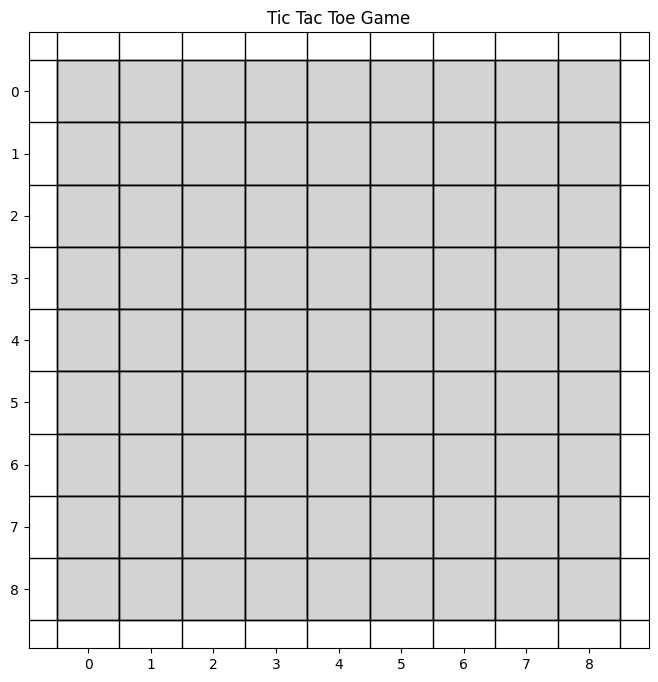

Board after 1 move


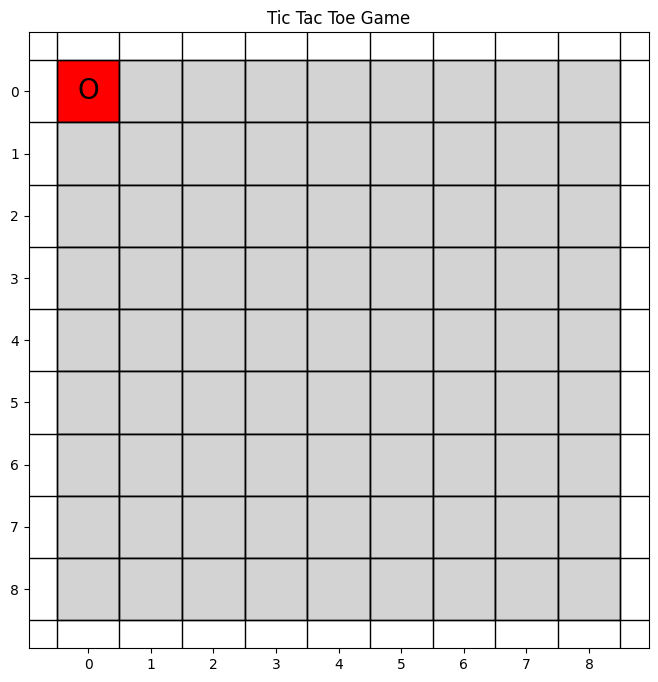

Board after 2 move


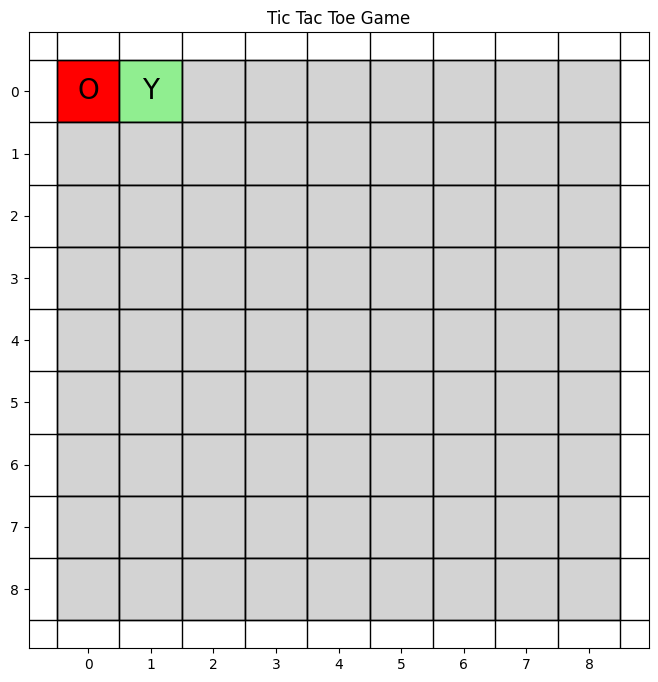

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
8 0
Board after 3 move


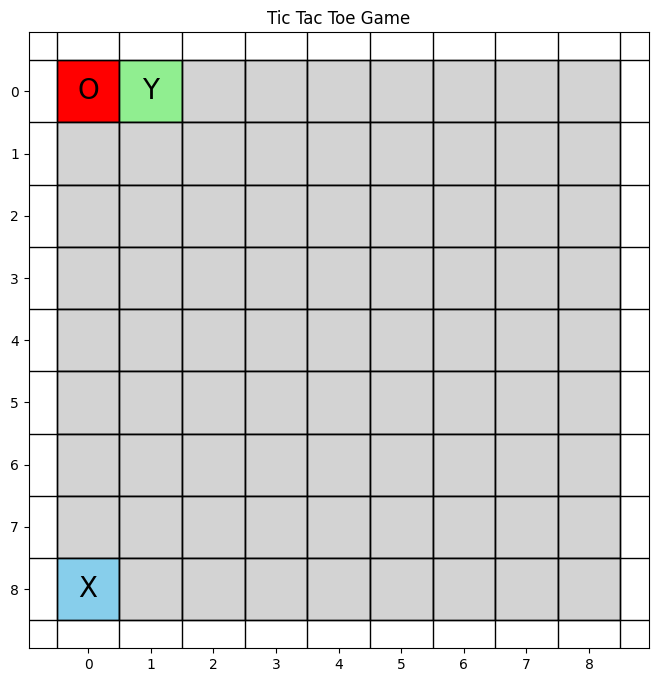

Board after 4 move


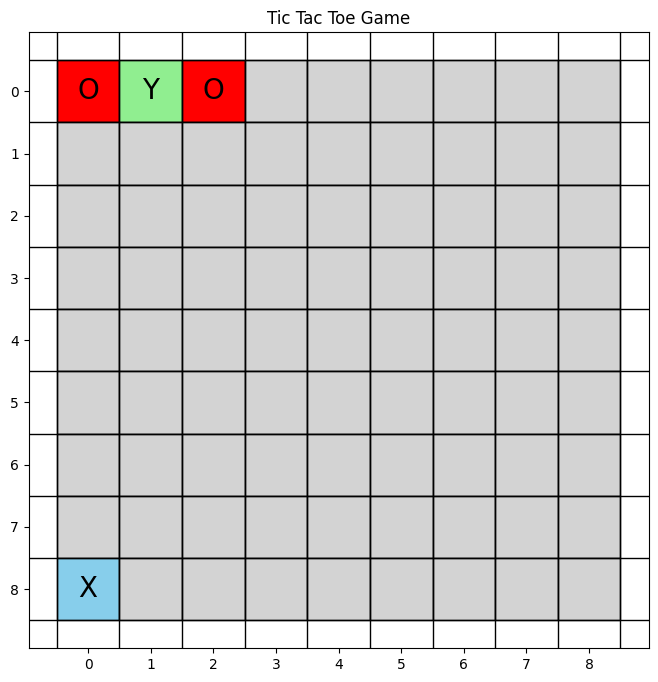

Board after 5 move


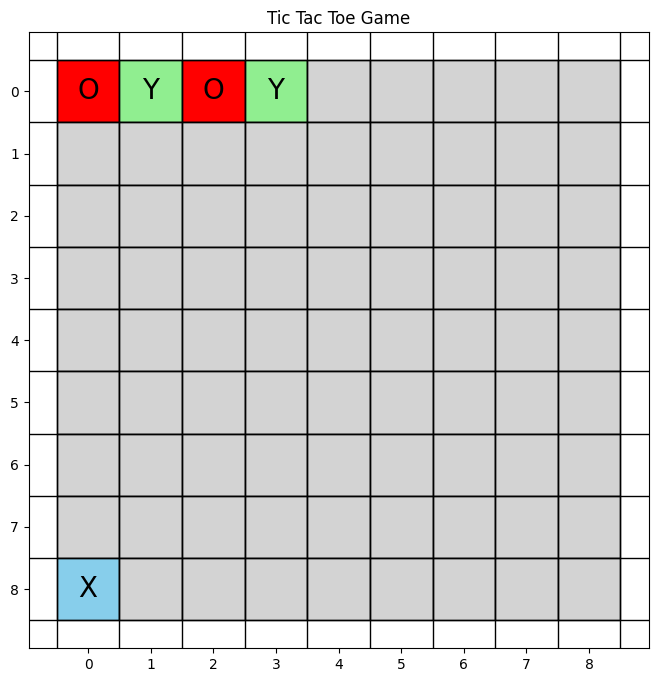

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
8 1
Board after 6 move


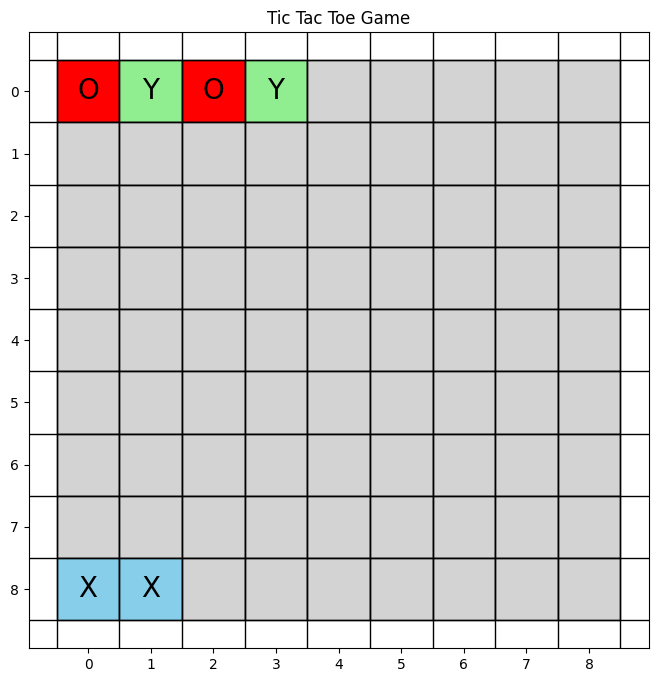

Board after 7 move


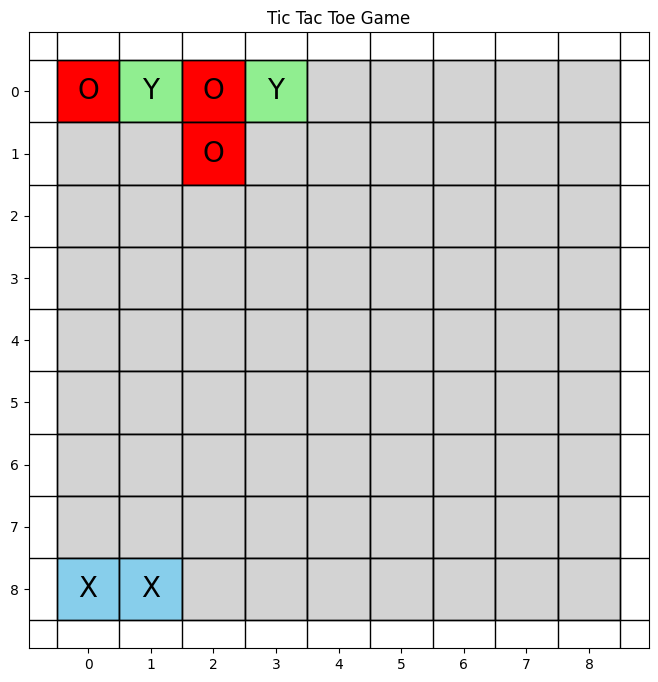

Board after 8 move


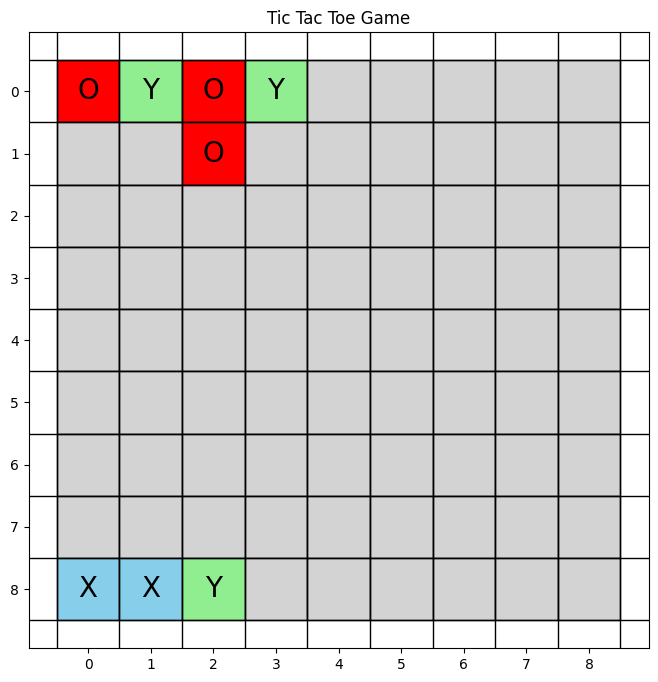

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
8 8
Board after 9 move


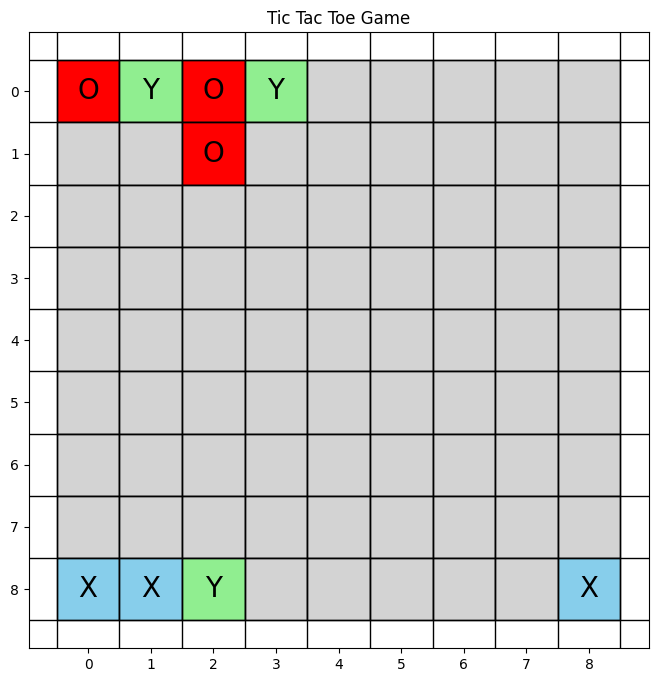

Board after 10 move


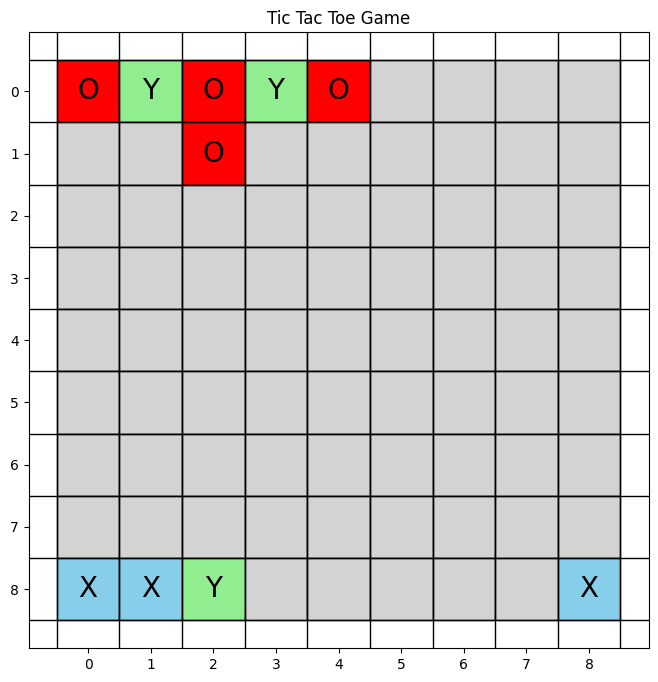

Board after 11 move


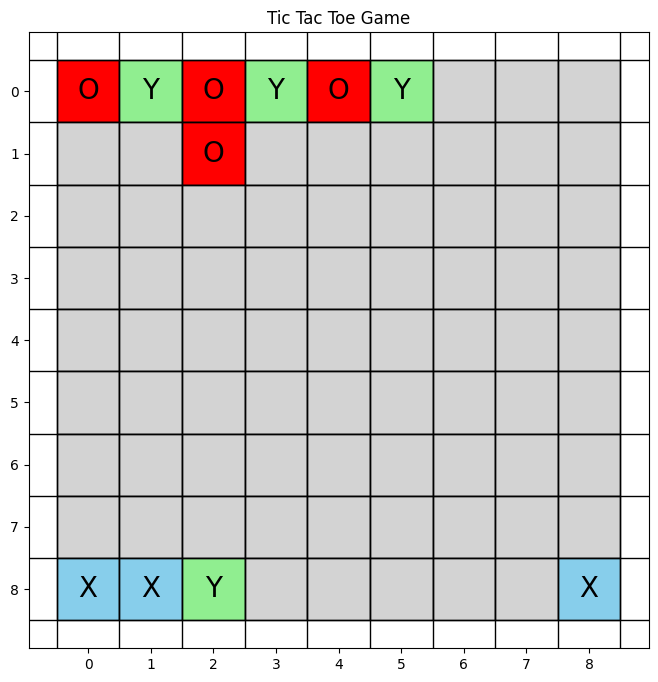

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
7 7
Board after 12 move


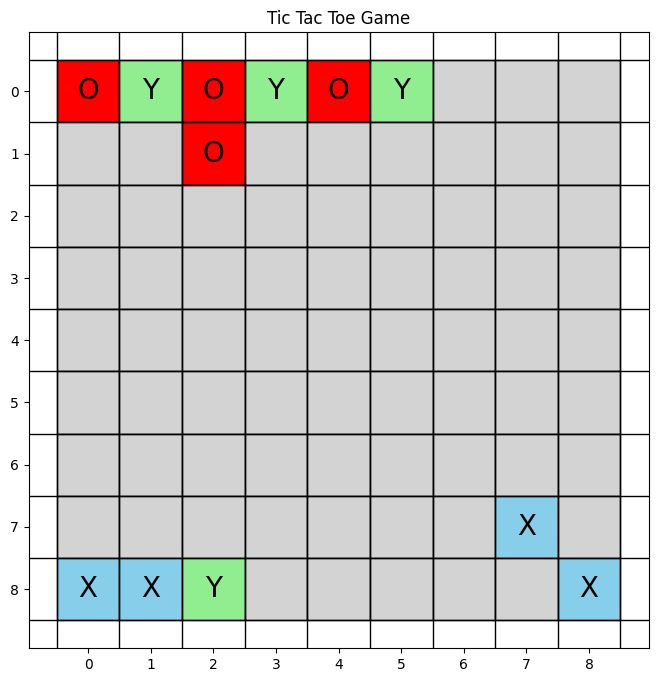

Board after 13 move


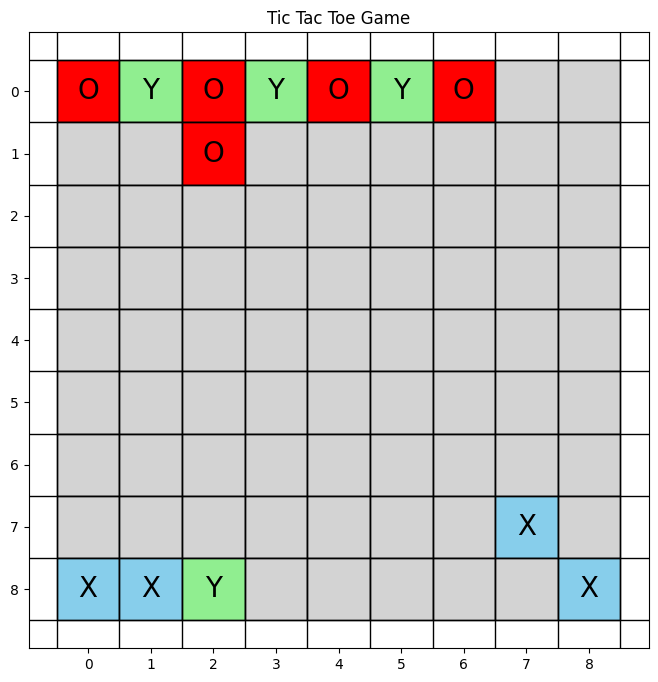

Board after 14 move


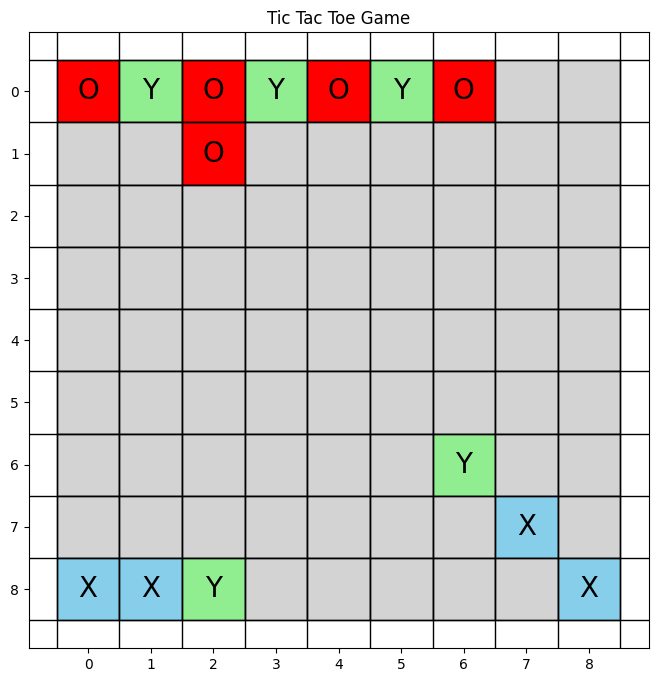

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
8 7
Board after 15 move


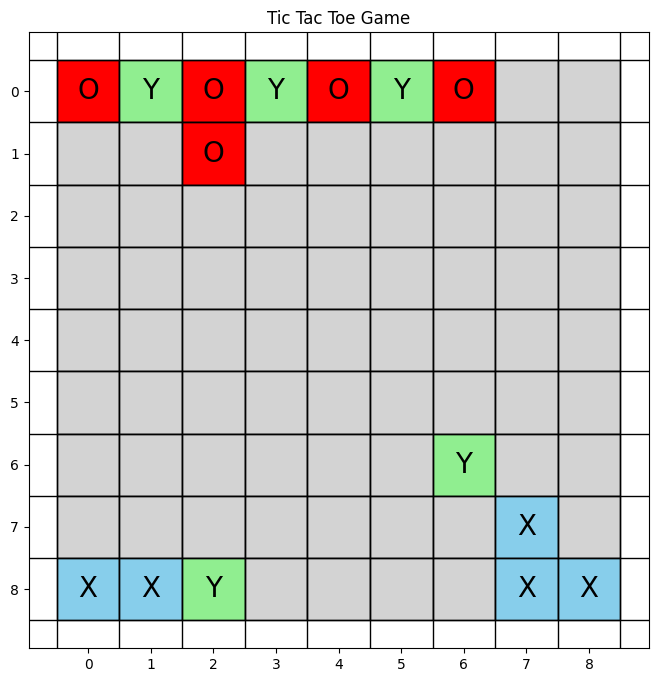

Board after 16 move


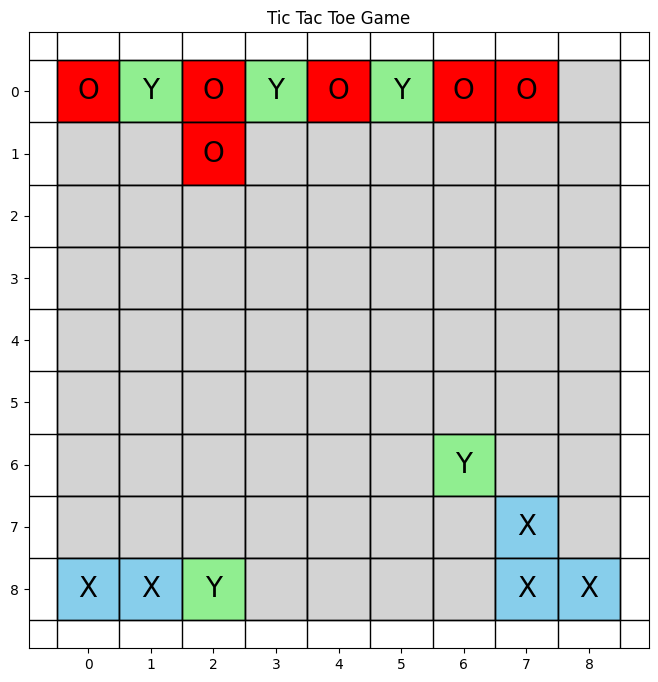

Board after 17 move


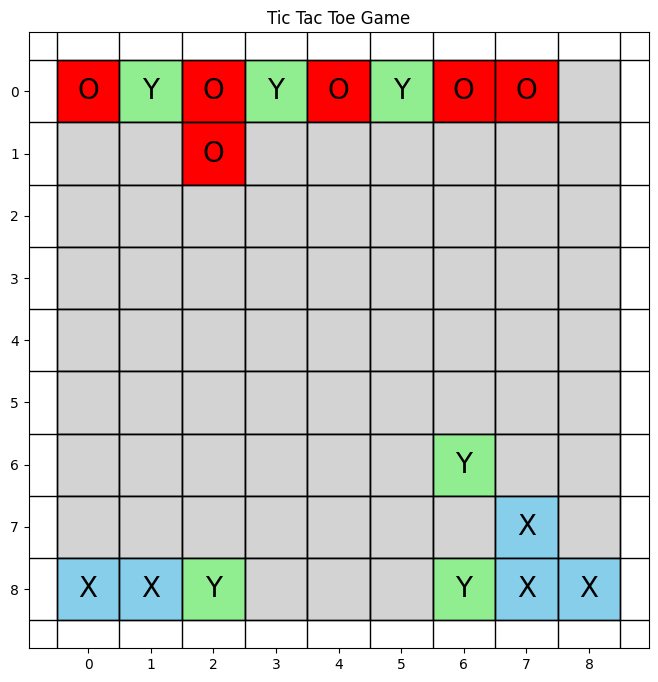

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
6 8
Board after 18 move


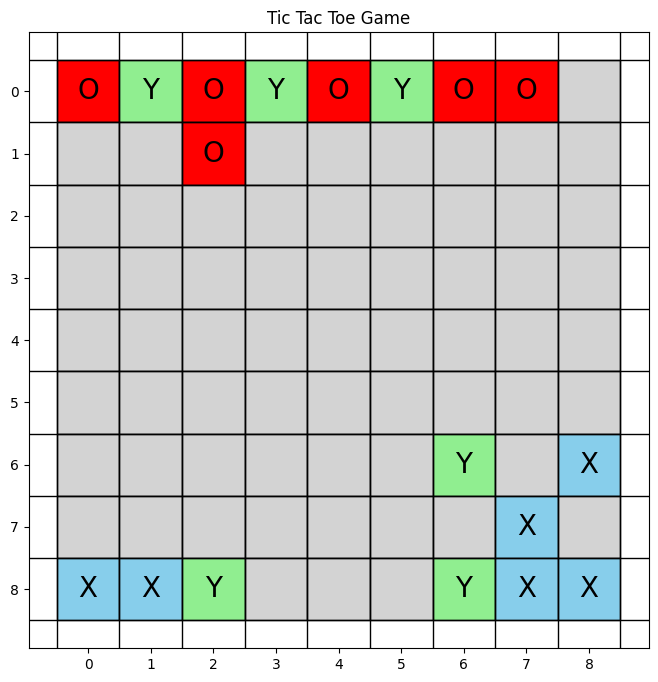

Board after 19 move


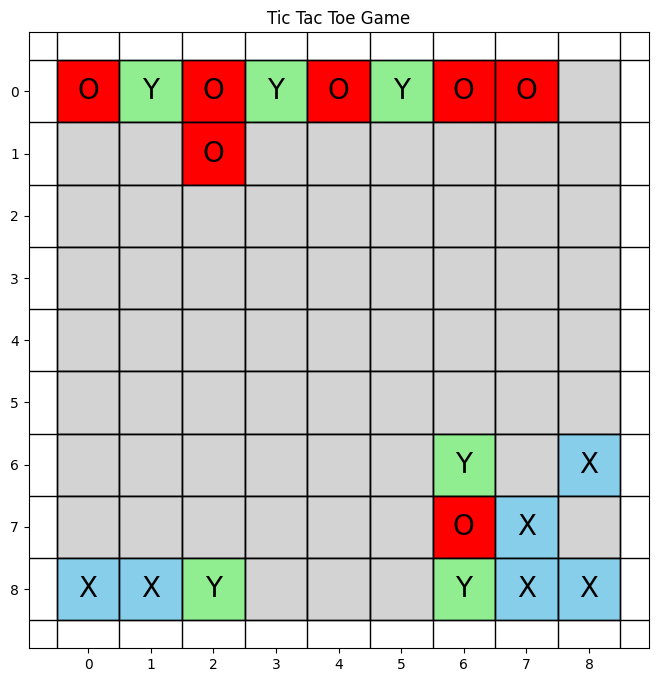

Board after 20 move


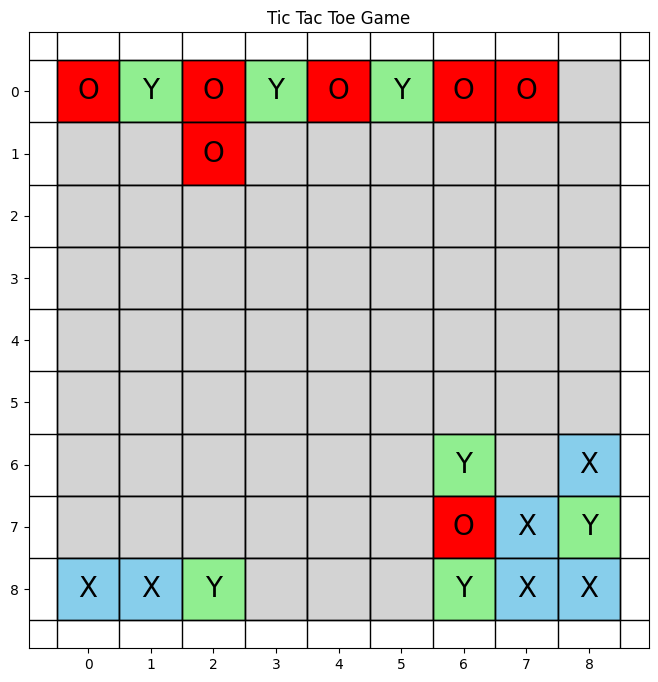

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
5 5
Board after 21 move


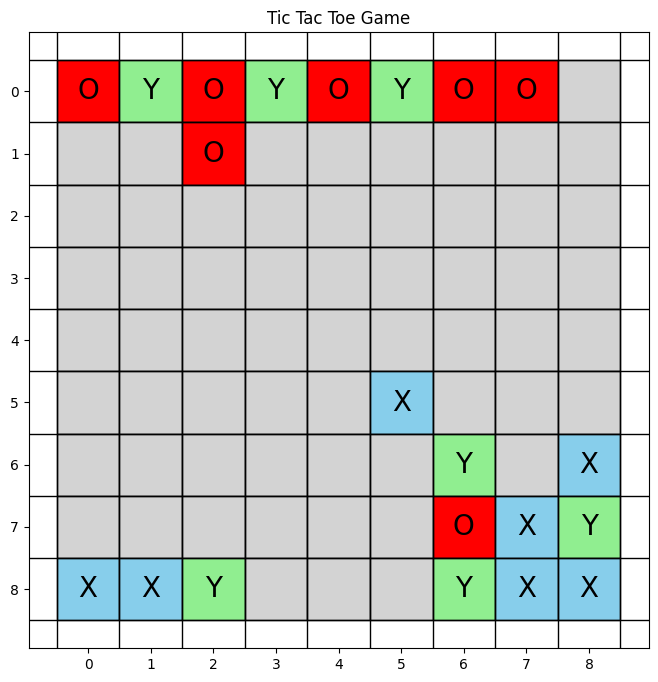

Board after 22 move


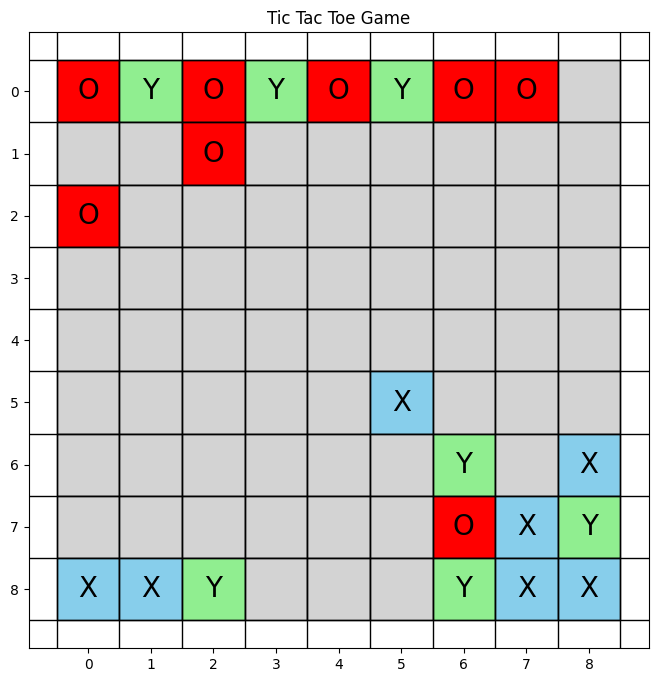

Board after 23 move


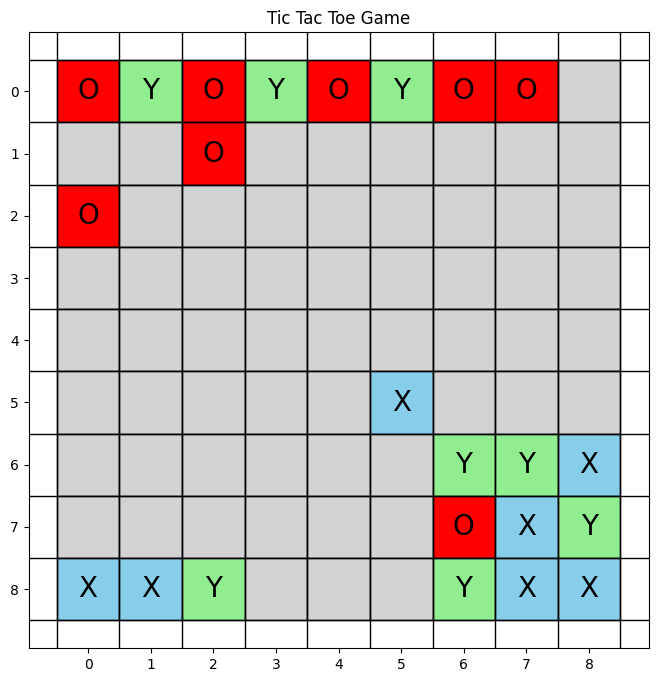

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
4 5
Board after 24 move


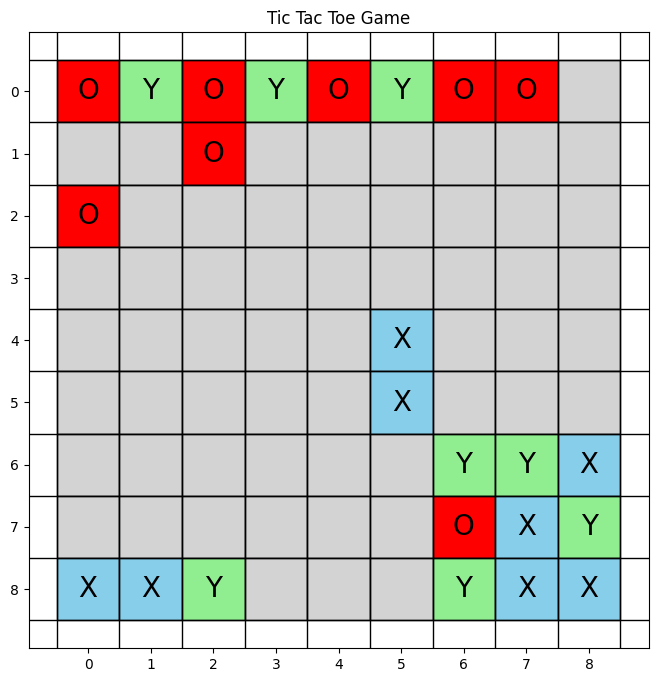

Board after 25 move


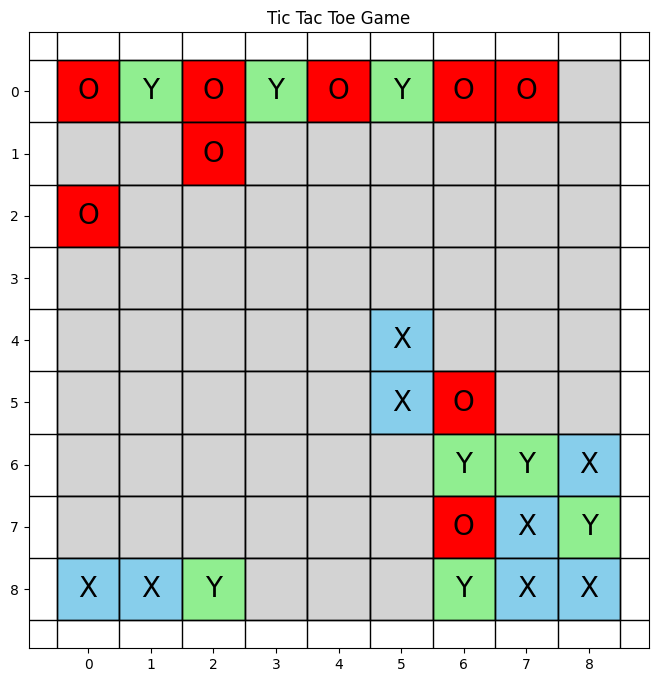

Board after 26 move


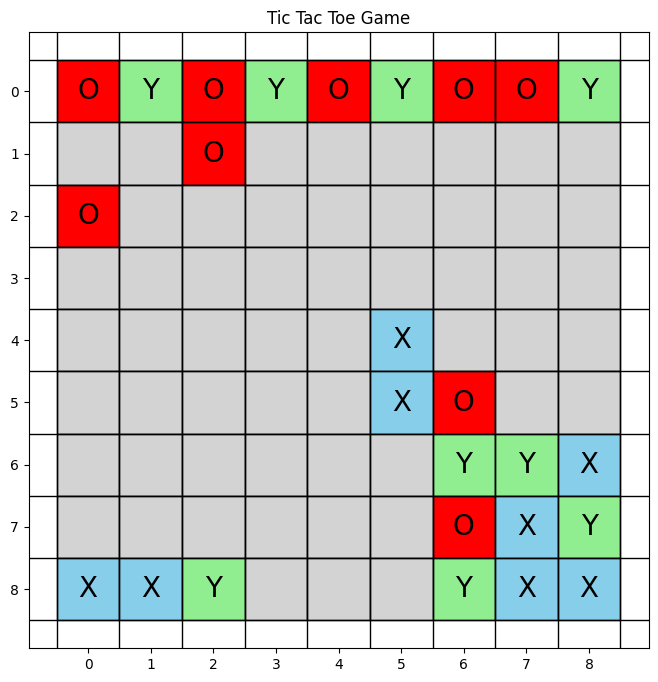

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
3 5
Board after 27 move


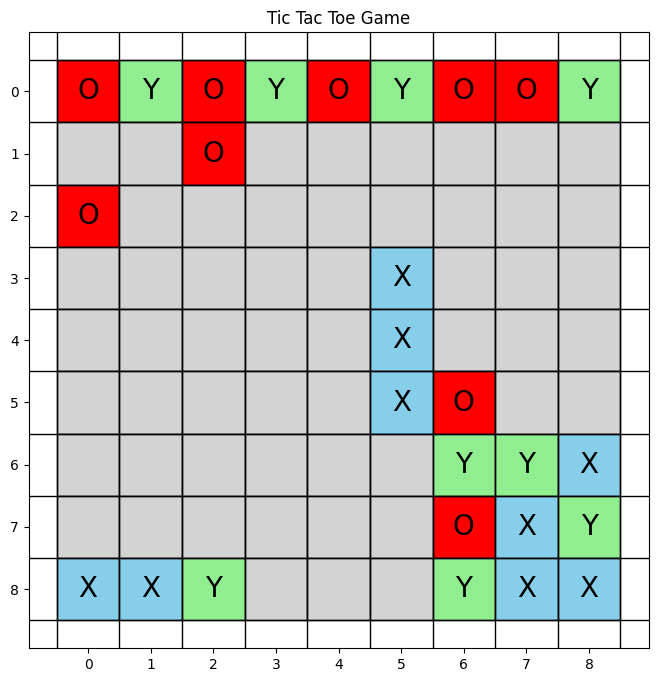

Board after 28 move


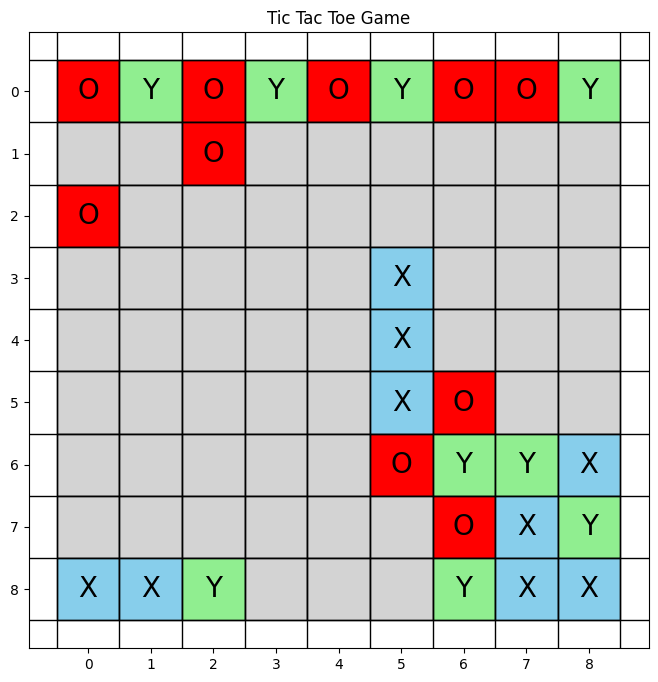

Board after 29 move


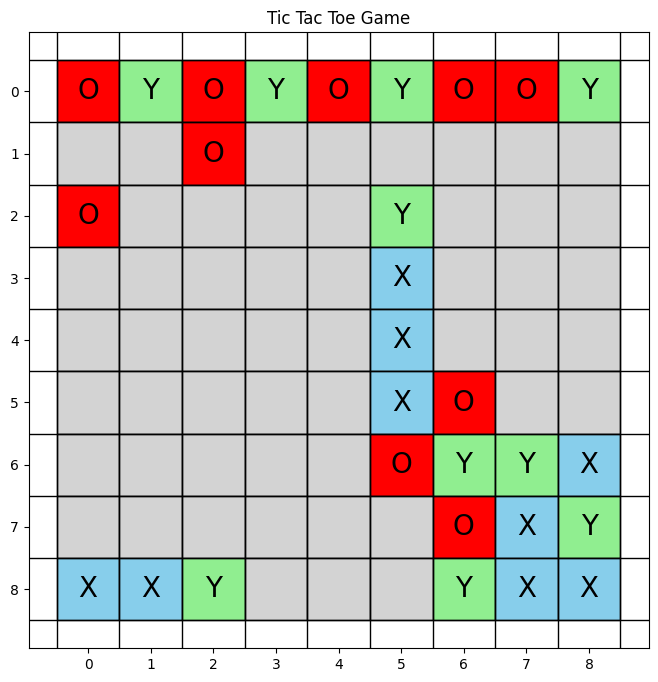

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
2 5
Invalid move, try again.
Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
5 2
Board after 30 move


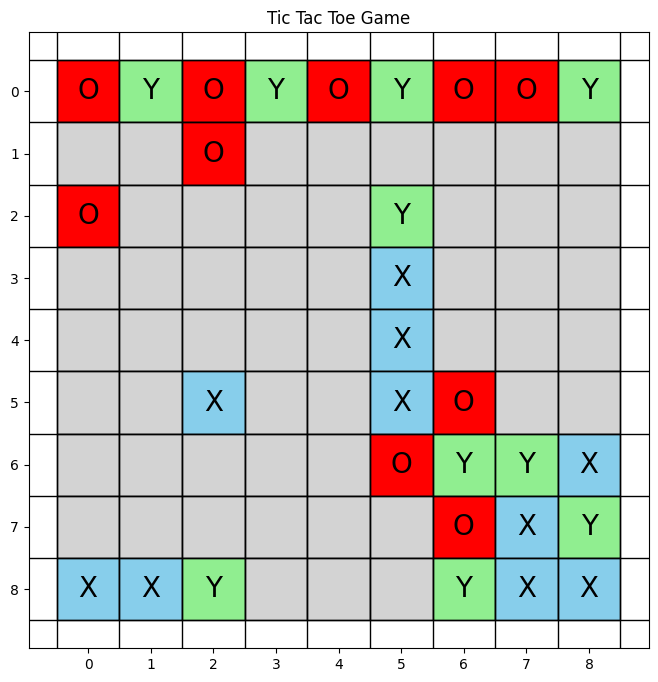

Board after 31 move


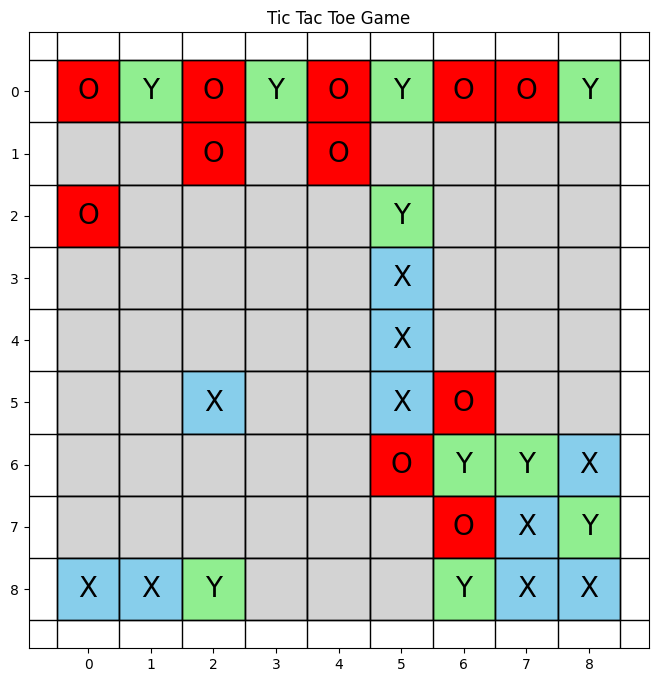

Board after 32 move


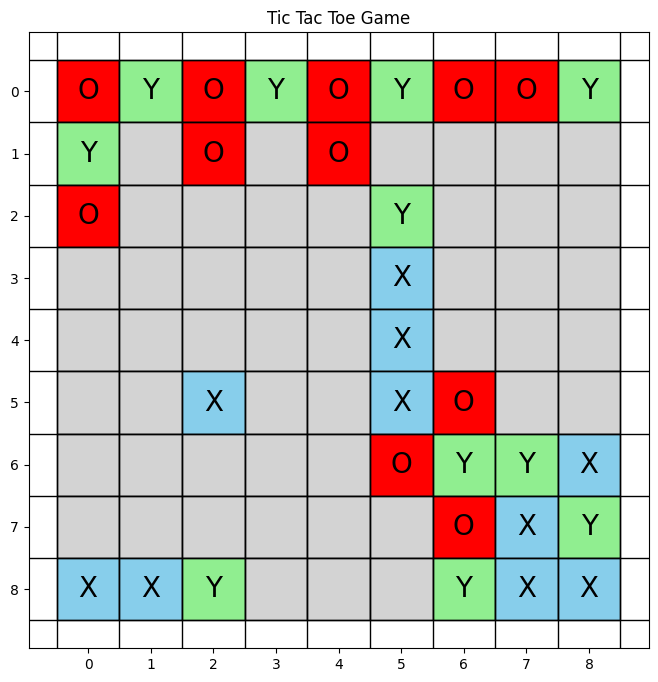

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
1 5
Board after 33 move


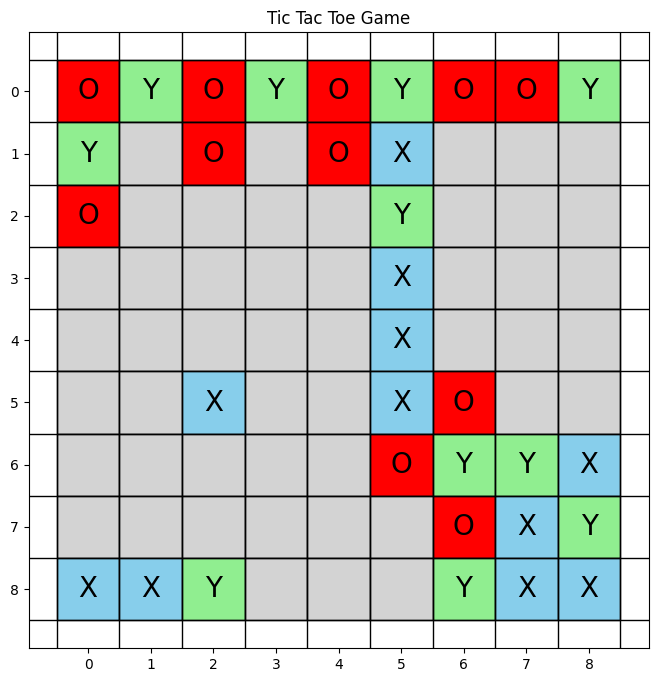

Board after 34 move


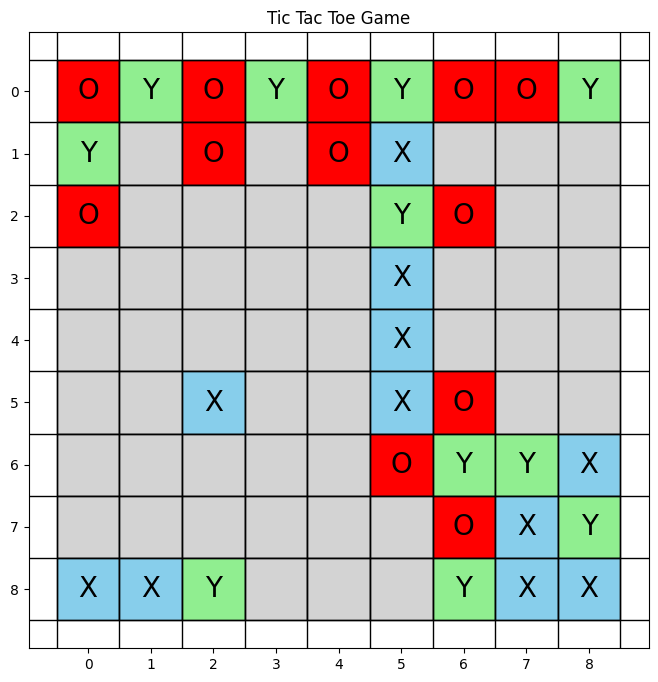

Board after 35 move


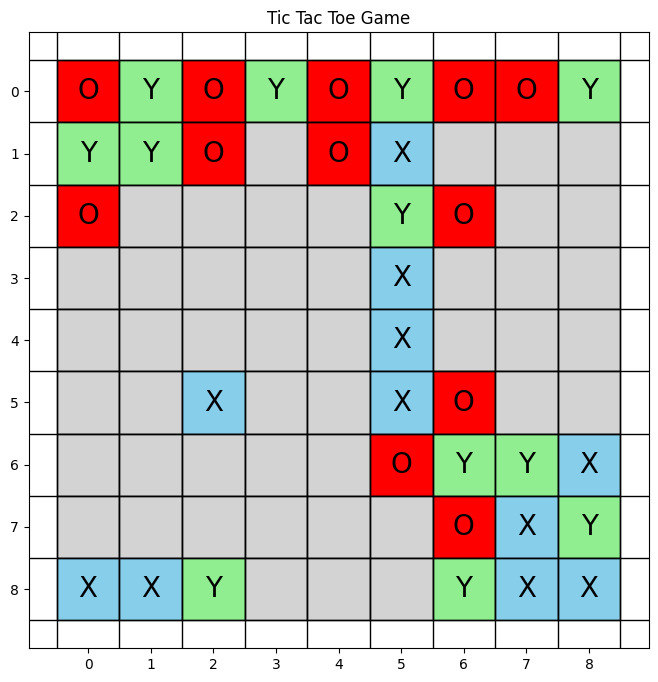

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
5 1
Board after 36 move


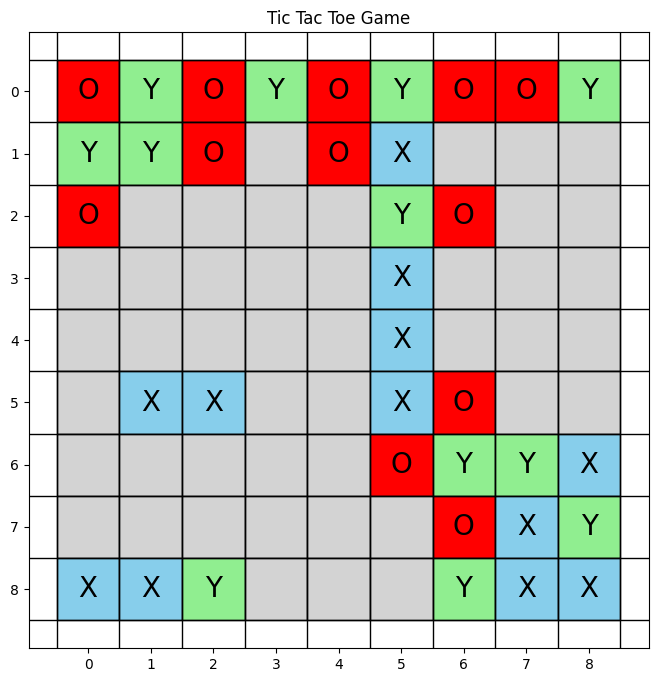

Board after 37 move


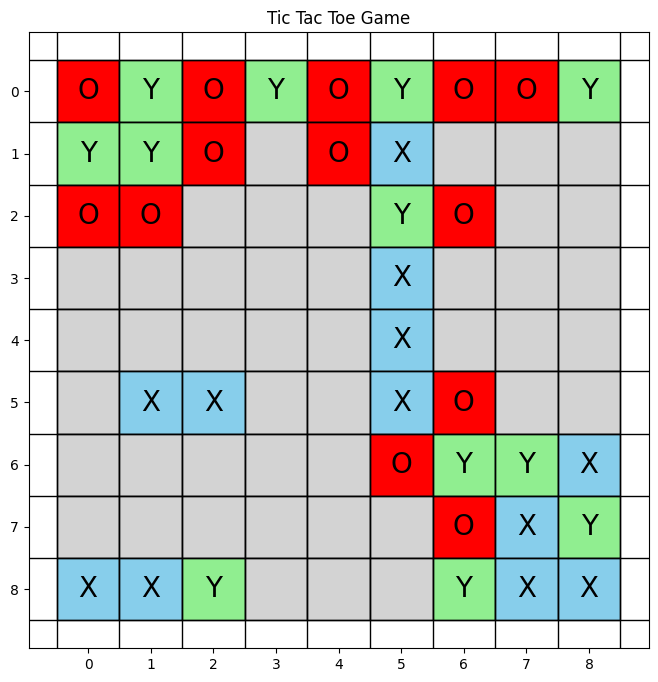

Board after 38 move


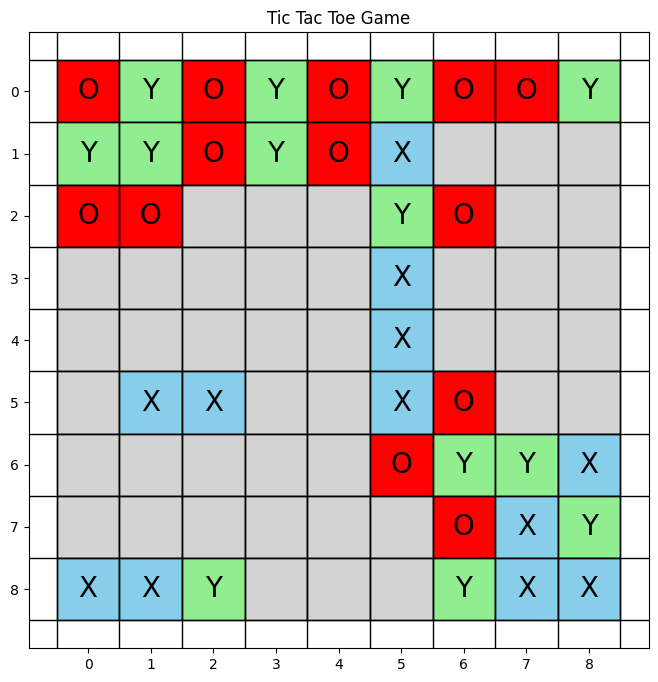

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
5 3
Board after 39 move


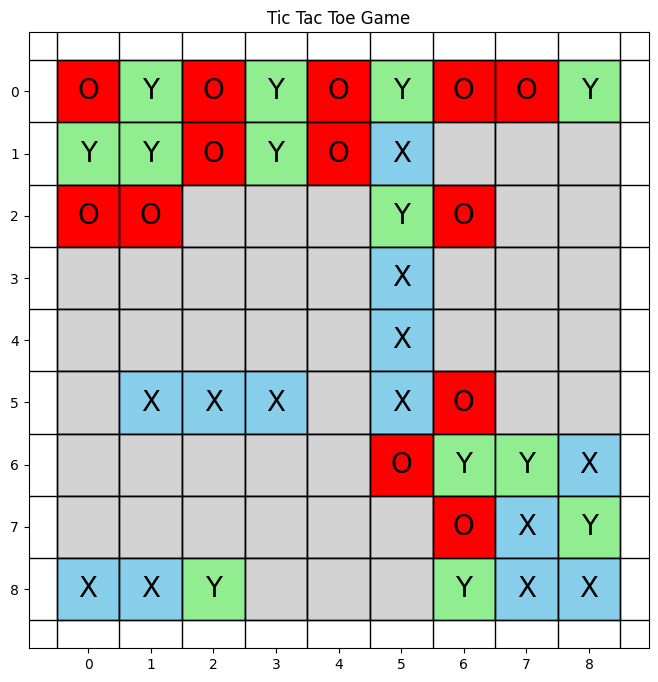

Board after 40 move


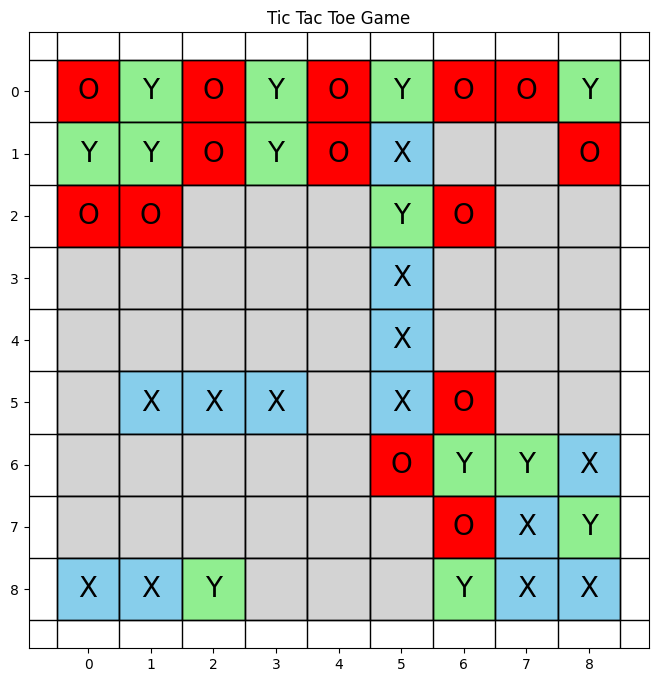

Board after 41 move


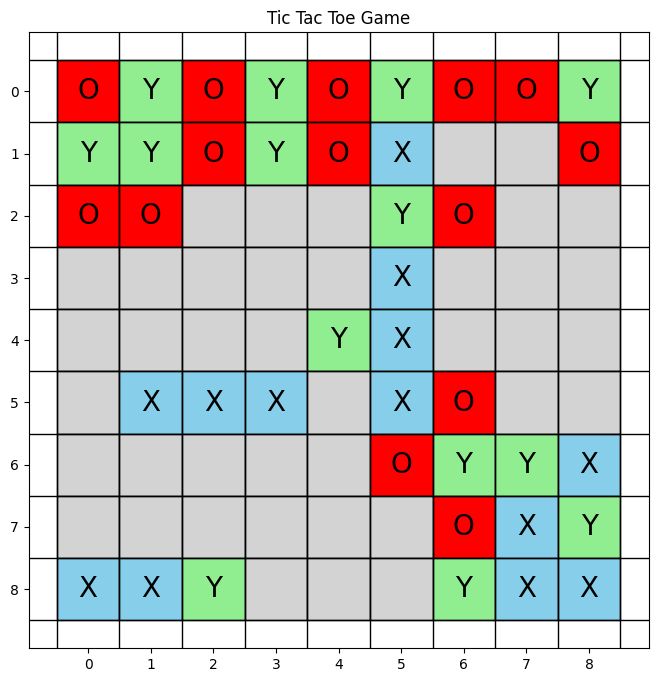

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
5 0
Board after 42 move


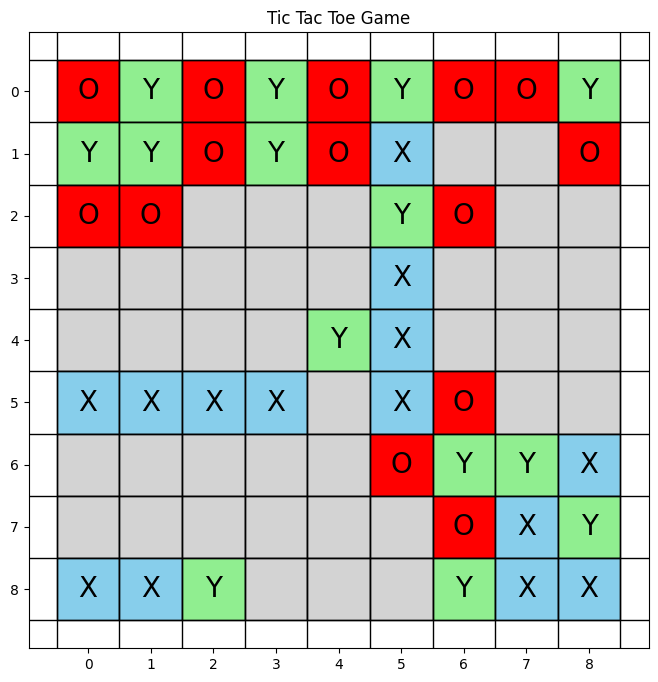

Board after 43 move


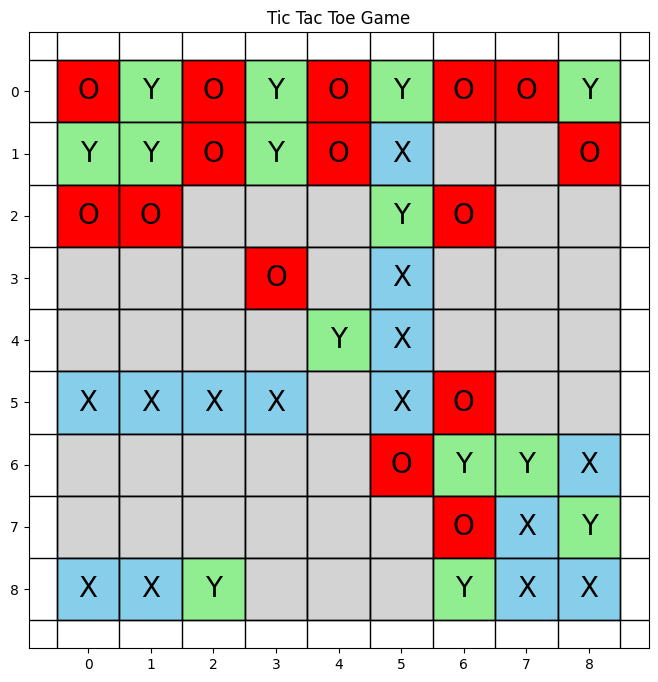

Board after 44 move


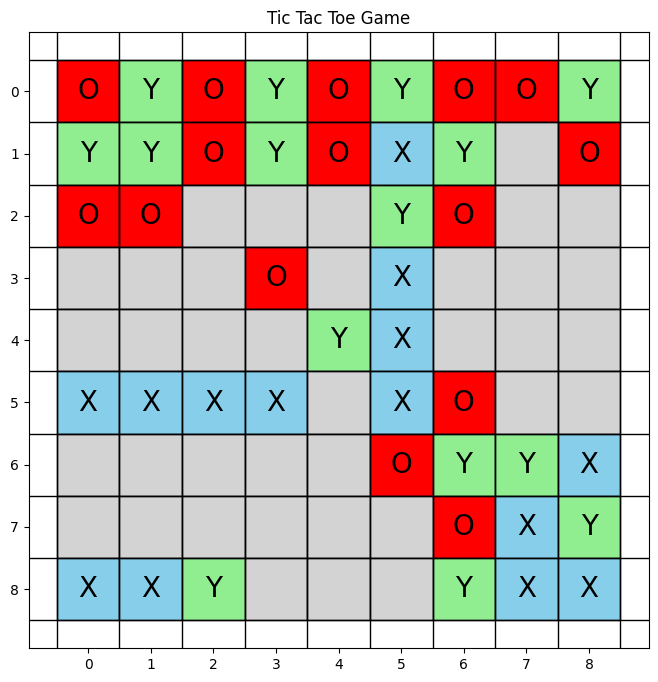

Turn for Human Player, Enter Row and Column below (0-8) with space. Eg. <rowno> <colno> (0 0): 
5 4
Board after 45 move


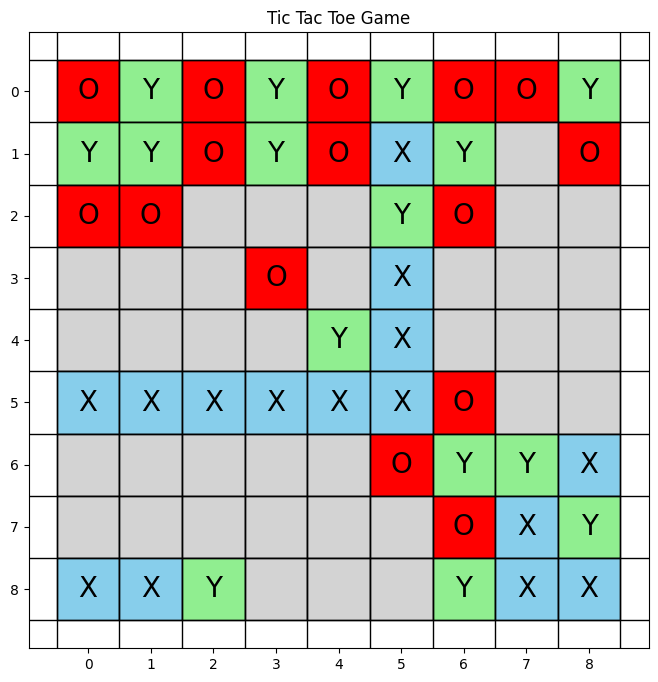

Winner is: Player 1 (Human)


In [ ]:
# Run this cell to start playing
print("Winner is: " + str(play_game()))